# Homework 4

**Total Points: 55 pts UG/66 pts G**

Add your code into the blocks below the prompt. You can add more blocks as needed by clicking the "+" symbol up to the left. This will add a new block below whichever block you have highlighted. You can change the block to be either "code" or "markdown" depending on your needs!

**IMPORTANT: Make sure you add comments to each of your code blocks explaining what is happening so someone else can replicate your code.**

In this homework, you will practice the methods of regression and begin to explore working with network data. For each problem I have provided suggested data you can use, but if your final project data or some other file fits the requirements, then please feel free to complete the assignment with that data instead. Specific requirements of the data are listed for each problem. 

## 4.1 Regression Modeling

**30 pts**

You may wish to use `lacounty_tracts.csv` for this problem. If you'd like to use your own data, the requirements are:
* Includes one outcome variable and more than 4 predictor variables for use in a regression model
* At least one of the predictor variables is categorical (you can create this column if needed)
* There must be a spatial component (e.g., lat/lon, geometry) (you can add this via census tracts, etc. if needed)



In [271]:
# Read in the data file 
# If you add your own data, add a """ docstring explanation """ of the data. Make sure to run .head() so we can see the columns
import pandas as pd 
import statsmodels.formula.api as smf

la = pd.read_csv('/Users/madilore/Documents/Cornell/Course Materials/IUS/2026/lacounty_tracts.csv')
la.head()


,GEOID,tot_pop,per_white,per_black,per_asian,per_hispanic,med_income,per_bach,per_age2534,per_age65up,...,h_value,singleh,vacant,hunit,dist_univ,area,dist_cent,per_age2024,maj_white,maj_singleh
0,6037101110,3923,75.095590,0.433342,10.349223,24.547540,74625.0,27.768540,12.898292,17.894469,...,502200.0,69.490485,11.479435,1629,11956.86865,1142401,7825.091764,3.8,True,True
1,6037101122,4119,79.145424,3.593105,10.342316,4.418548,93125.0,34.109764,10.755038,21.291576,...,658800.0,100.000000,4.623044,1406,12417.87742,2644045,7994.963702,7.8,True,True
2,6037101220,3775,61.218543,2.490066,10.331126,40.291391,55682.0,26.196566,13.271523,14.198676,...,550800.0,66.552668,12.859097,1462,11578.64416,698886,6970.598458,5.5,True,True
3,6037101221,3787,66.675469,5.624505,7.050436,31.212041,46274.0,23.973114,9.928703,15.104304,...,461600.0,24.633057,8.296107,1567,11737.07139,354178,7458.141870,6.9,True,False
4,6037101222,2717,85.719544,0.147221,2.392344,43.503865,30016.0,17.066806,12.366581,14.942952,...,378400.0,11.764706,5.983773,986,11534.83108,296512,7105.370752,8.1,True,False


Run a regression model on the data. If you are using `lacounty_tracts.csv`, regress housing values (`h_value`) on distance to the city center (`dist_cent`). Control for white, black, asian, and hispanic population percentages, percent bachelor's degrees or higher (`per_bach`), and percent of people 65+ (`per_age65up`). 

If you are using your own data, choose an outcome variable, a predictor variable, and at least 2 confounding variables. Add a description for why you are including each variable. 

In [272]:
model1 = smf.ols(formula='h_value ~ dist_cent + per_white + per_black + \
                per_asian + per_hispanic + per_bach + per_age65up', data=la).fit()

model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                h_value   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     535.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:17:03   Log-Likelihood:                -32298.
No. Observations:                2353   AIC:                         6.461e+04
Df Residuals:                    2345   BIC:                         6.466e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.754e+05   6.72e+04      2.609      0.009    4.35e+04    3.07e+05
dist_cent        1.2783      2.202      0.580      0.562      -3.040       5.597
per_white    -1203.1419    550.583     -2.185      0.029   -2282.821    -123.463
per_black    -2546.5724    730.269     -3.487      0.000   -3978.612   -1114.533
per_asian    -4124.5345    666.774     -6.186      0.000   -5432.062   -2817.007
per_hispanic  1126.1768    483.914      2.327      0.020     177.234    2075.120
per_bach      1.443e+04    490.969     29.391      0.000    1.35e+04    1.54e+04
per_age65up   7398.3378    872.655      8.478      0.000    5687.081    9109.594
==============================================================================
Omnibus:                      486.031   Durbin-Watson:                   1.105
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1494.257
Skew:                           1.044   Prob(JB):                         0.00
Kurtosis:                       6.299   Cond. No.                     4.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Check the correlations between your predictor variables. Run VIF on any that are concerning. 

In [273]:
la[['dist_cent','per_white','per_black','per_asian','per_hispanic','per_bach','per_age65up']].corr()


,dist_cent,per_white,per_black,per_asian,per_hispanic,per_bach,per_age65up
dist_cent,1.000000,-0.099707,0.093627,-0.109095,0.178282,-0.268634,-0.062683
per_white,-0.099707,1.000000,-0.392165,-0.388854,-0.332456,0.455805,0.183162
per_black,0.093627,-0.392165,1.000000,-0.219904,-0.075886,-0.157058,-0.077557
per_asian,-0.109095,-0.388854,-0.219904,1.000000,-0.412560,0.320491,0.283983
per_hispanic,0.178282,-0.332456,-0.075886,-0.412560,1.000000,-0.851074,-0.488669
per_bach,-0.268634,0.455805,-0.157058,0.320491,-0.851074,1.000000,0.377313
per_age65up,-0.062683,0.183162,-0.077557,0.283983,-0.488669,0.377313,1.000000


In [274]:
lm_vif=smf.ols(formula='per_hispanic ~ dist_cent + per_white + per_black + \
                per_asian + per_bach + per_age65up', data=la).fit()
print("VIF for per_hispanic is ", 1/(1-lm_vif.rsquared))



VIF for per_hispanic is  8.21070854211946


Interpret the model results. Use markdown language. 
* How good is the model fit?
* Which variables are significant?
* Interpret the coefficient of the predictor variable.
* Make an overall statement about your model. What is the big takeaway? 

Model fit is pretty high (.7), All but dist_center significant. For every one meter/unit increase in distance to the center city, home values increase $1.2783, though not significant. 
Home values decrease with higher percent older, white, asian, and bachelor's degrees increase. Home values increase as percent hispanic increases. 


Add a categorical variable into your model. For `lacounty_tracts.csv`, add whether the tract has majority single family homes or not (`maj_singleh`).  

In [275]:
model2 = smf.ols(formula='h_value ~ dist_cent + per_white + per_black + \
                per_asian + per_hispanic + per_bach + per_age65up + maj_singleh', data=la).fit()

model2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                h_value   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     468.9
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:17:05   Log-Likelihood:                -32296.
No. Observations:                2353   AIC:                         6.461e+04
Df Residuals:                    2344   BIC:                         6.466e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             1.77e+05   6.72e+04      2.634      0.008    4.52e+04    3.09e+05
maj_singleh[T.True]  1.717e+04   1.02e+04      1.683      0.093   -2837.629    3.72e+04
dist_cent               0.6131      2.237      0.274      0.784      -3.773       4.999
per_white           -1256.8504    551.292     -2.280      0.023   -2337.921    -175.780
per_black           -2577.4571    730.214     -3.530      0.000   -4009.390   -1145.524
per_asian           -4199.9728    668.019     -6.287      0.000   -5509.943   -2890.003
per_hispanic         1054.8839    485.576      2.172      0.030     102.680    2007.087
per_bach             1.447e+04    491.233     29.447      0.000    1.35e+04    1.54e+04
per_age65up          7010.4073    902.258      7.770      0.000    5241.101    8779.713
==============================================================================
Omnibus:                      491.339   Durbin-Watson:                   1.100
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1482.068
Skew:                           1.061   Prob(JB):                         0.00
Kurtosis:                       6.257   Cond. No.                     4.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Interpret the model results. Use markdown language. 
* Interpret the coefficient of the categorical variable.
* How did the coefficient of your predictor variable change? What is the impact of adding this variable?

Home values increase as you move from non-majority white tracts to majority white tracts. Distance to the city center became weaker, but still not significant.

Build a k-nearest neighbors model from the data, using k=4. Then compute the spatial lag model. 

In [276]:
## Add spatial data to tracts
# We need the geometries from the census 
year=2020
state_fips='06'
url = f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/tl_{year}_{state_fips}_tract.zip"
tracts = gpd.read_file(url)

la['GEOID'] = '0' + la['GEOID'].astype(str)
la = pd.merge(left=la, right=tracts, how='left', on='GEOID')
la = gpd.GeoDataFrame(la,
                         geometry='geometry', 
                         crs='EPSG:4326')


from libpysal import weights
la_not_na = la.dropna()
w_knn = weights.KNN.from_dataframe(la_not_na, k=4)
w_knn.set_transform("R") 
y = la_not_na['h_value']
y_lag = weights.lag_spatial(w_knn, y)

data_lag = pd.DataFrame(data={"MedIncome": y, "MedIncome_lag": y_lag}).astype(int)
data_lag

# They should have to include the spatial data, but if they do it another way or perhaps read in 
# another version of latracts where we've already added this that is totally fine. 



,MedIncome,MedIncome_lag
0,502200,512400
1,658800,461350
2,550800,496350
3,461600,496425
4,378400,517225
...,...,...
2455,382700,571725
2456,509600,980375
2466,868400,711500
2475,937500,2000001


Build a k-nearest neighbors model from the data, using k=?. Justify your choice of k, compare it to k=4. Compute the spatial lag model. 

In [277]:
w_knn = weights.KNN.from_dataframe(la_not_na, k=8)
w_knn.set_transform("R") 
y = la_not_na['h_value']
y_lag = weights.lag_spatial(w_knn, y)

data_lag = pd.DataFrame(data={"MedIncome": y, "MedIncome_lag": y_lag}).astype(int)
data_lag


,MedIncome,MedIncome_lag
0,502200,540300
1,658800,520725
2,550800,540100
3,461600,551250
4,378400,561650
...,...,...
2455,382700,555137
2456,509600,942237
2466,868400,714287
2475,937500,1865013


## 4.2 Networks

**16 pts UG/20 pts G**

Download the street network for Ithaca and plot it. 

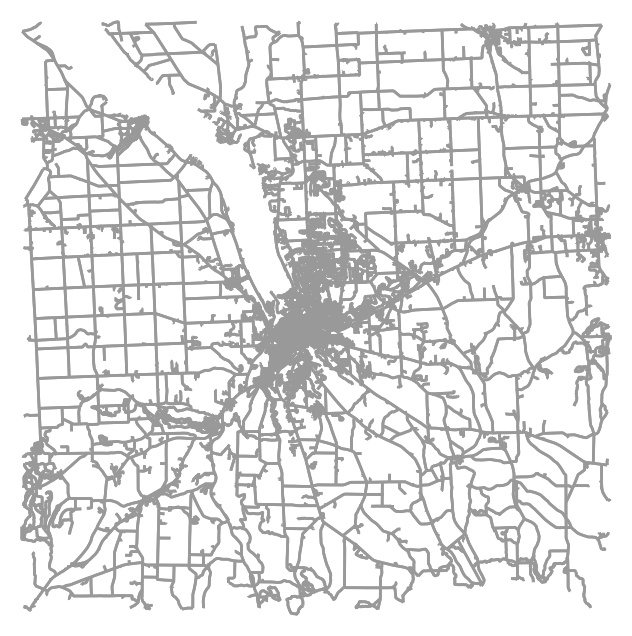

In [278]:
import osmnx as ox 

#place = "Tompkins, New York, USA"
#G = ox.graph.graph_from_place(place, network_type="walk")

location_point = (42.450896, -76.484448)
# create network from point, inside bounding box of N, S, E, W each 750m from point
G = ox.graph.graph_from_point(location_point, dist=16000, dist_type="bbox", network_type="walk")

fig, ax = ox.plot.plot_graph(G, bgcolor='white', edge_linewidth=2, node_size=0)


Download the locations of all of the tagged parks in Ithaca. Add them to your plot with the road network. 

<Axes: >

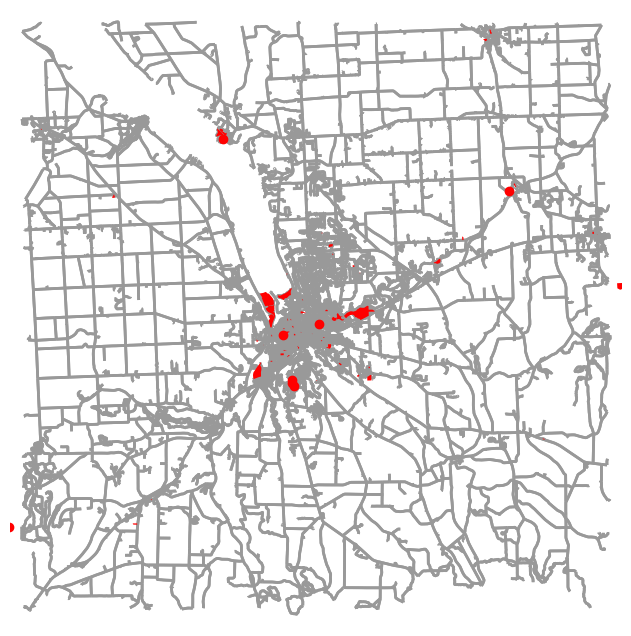

In [279]:
tags = {"leisure": "park"}
gdf1 = ox.features.features_from_place(place, tags)
fig, ax = ox.plot.plot_graph(G, bgcolor='white', edge_linewidth=2, node_size=0, show=False, close=False)
gdf1.plot(ax=ax, color='red')


Find the nodes closest to Sibley Hall and Stewart Park and map the shortest route between them based on distance traveled and time traveled separately. 

In [280]:
# Sibley Hall 
sibley_node = ox.distance.nearest_nodes(G, X=-76.484448, Y=42.450896)
# Stewart Park
stewart_park_node = ox.distance.nearest_nodes(G, X=-76.506541, Y=42.453492)
print(sibley_node)
print(stewart_park_node)


1043464237
213442784


In [281]:
G = ox.routing.add_edge_speeds(G) # in km per hour
G = ox.routing.add_edge_travel_times(G) # in seconds 

distance_route = ox.routing.shortest_path(G, sibley_node, stewart_park_node) #, weight="length")
time_route = ox.routing.shortest_path(G, sibley_node, stewart_park_node, weight="travel_time")


Plot the two routes. How do they compare? Add your answer in Markdown format. 

(<Figure size 800x800 with 1 Axes>, <Axes: >)

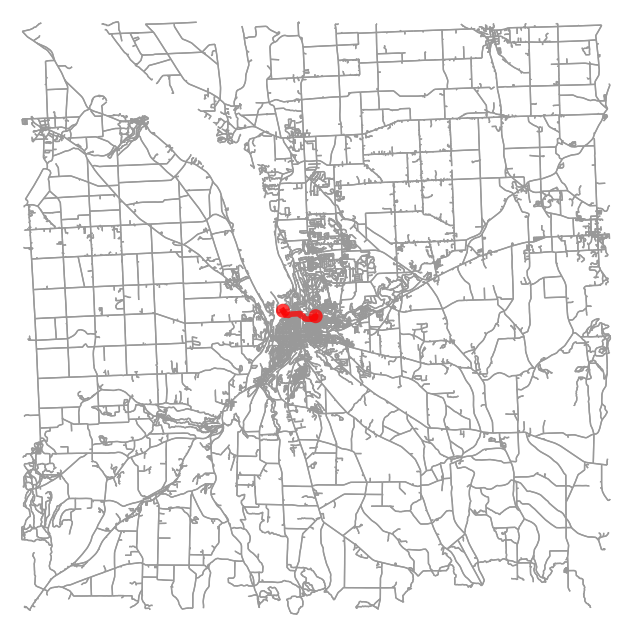

In [282]:
fig, ax = ox.plot.plot_graph_route(G, distance_route, bgcolor='white', node_size=0, show=False, close=False)
ox.plot.plot_graph_route(G, time_route, ax=ax, bgcolor='white', node_size=0, show=False, close=False)



**Graduate students only** Plot the road network, but color the nodes based on the walking time to the nearest park. 

In [283]:
# First get nearest network node to each park
gdf['centroid'] = gdf.geometry.centroid
gdf['X'] = gdf['centroid'].x
gdf['Y'] = gdf['centroid'].y
gdf['nearest_node'] = gdf.apply(lambda row: ox.distance.nearest_nodes(G, X=row.X, Y=row.Y), axis=1)
gdf.head()



/var/folders/p3/nl4g9f296vj7y7kcrk8f76380000gn/T/ipykernel_95451/254980836.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid


,stop_id,stop_code,stop_name,stop_desc,platform_code,platform_name,stop_lat,stop_lon,zone_id,stop_address,...,route_sort_order,route_fare_class,line_id,listed_route,network_id,geometry,centroid,X,Y,nearest_node
0,70061,70061.0,Alewife,Alewife - Red Line,NaN,Red Line,42.396148,-71.140698,RapidTransit,NaN,...,10010,Rapid Transit,line-Red,NaN,rapid_transit,POINT (-71.1407 42.39615),POINT (-71.1407 42.39615),-71.140698,42.396148,213561642
1,70126,70126.0,Allston Street,Allston Street - Green Line - Park Street & North,NaN,Park Street & North,42.348649,-71.137881,RapidTransit,NaN,...,10032,Rapid Transit,line-Green,NaN,rapid_transit,POINT (-71.13788 42.34865),POINT (-71.13788 42.34865),-71.137881,42.348649,7515699919
2,70127,70127.0,Allston Street,Allston Street - Green Line - (B) Boston College,NaN,Boston College,42.348546,-71.137362,RapidTransit,NaN,...,10032,Rapid Transit,line-Green,NaN,rapid_transit,POINT (-71.13736 42.34855),POINT (-71.13736 42.34855),-71.137362,42.348546,7515699919
3,170140,170140.0,Amory Street,Amory Street - Green Line - Park Street & North,NaN,Park Street & North,42.350901,-71.114318,RapidTransit,NaN,...,10032,Rapid Transit,line-Green,NaN,rapid_transit,POINT (-71.11432 42.3509),POINT (-71.11432 42.3509),-71.114318,42.350901,7515699919
4,170141,170141.0,Amory Street,Amory Street - Green Line - (B) Boston College,NaN,Boston College,42.351066,-71.115027,RapidTransit,NaN,...,10032,Rapid Transit,line-Green,NaN,rapid_transit,POINT (-71.11503 42.35107),POINT (-71.11503 42.35107),-71.115027,42.351066,7515699919


In [284]:
# Turn nodes into a gdf
G_proj = ox.projection.project_graph(G) # This changes the underlying crs of the network to local meters
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
print(nodes_proj.crs)
gdf = gdf.to_crs("EPSG:32618")
print(gdf.crs) # convert parks crs
gdf.crs

EPSG:32618
EPSG:32618


<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [285]:
# Save the node ID for the closest park to each G.node
park_nodes = []
for idx, row in nodes_proj.iterrows():
    gdf['distances'] = gdf.distance(row.geometry) # Get the distances for every park to this one node
    best_node = gdf[gdf.distances == gdf.distances.min()].nearest_node.iloc[0] # Save the nearest_node ID for the smallest distance
    park_nodes.append(best_node) # keep this ID


In [286]:
# Add the park nodes as a column to the node gdf
nodes_proj['park_node'] = park_nodes
origs = list(nodes_proj.index) # Get list of origins
dests = list(nodes_proj.park_node.values) # Get list of destinations

In [287]:
# Add walking times to the network
import networkx as nx 
# First set walking speed to 5 kph
walking_speeds = {edge: 5 for edge in G.edges}
nx.set_edge_attributes(G, walking_speeds, "speed_kph")

# Then compute walking time
G = ox.routing.add_edge_travel_times(G) # in seconds 

In [295]:
# Compute the routes between each node and its closest park node
routes = ox.routing.shortest_path(G, origs, dests, weight="travel_time", cpus=1)

In [ ]:
# Get total travel times
def get_travel_times(route):
    """Get the sum of travel times along each route"""
    edges = list(zip(route, route[1:])) # Zip up edges
    time = sum([G[x[0]][x[1]][0]['travel_time'] for x in edges]) # Sum up edge attributes
    return time

all_times = [get_travel_times(route) for route in routes] # Run for each route
node_times = {node: node_time for node, node_time in zip(G.nodes(), all_times)} # Set as node attribute
nx.set_node_attributes(G, node_times, "walking_time")

In [ ]:
# Set color and plot
nc = ox.plot.get_node_colors_by_attr(G, "walking_time", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, node_color=nc, bgcolor='white', edge_linewidth=1, node_size=1)

## 4.3 GTFS Data 
**(9 pts UG/16 pts G)**

Download the GTFS data from a new city that we did not cover in class. 

Plot the main routes (subway, light rail, express bus, etc.). Color the routes either by their named colors or by their category (subway, commuter rail, etc.). 

In [289]:
import pandas as pd
import geopandas as gpd

stops = pd.read_csv('MBTA_GTFS/stops.txt')
routes = pd.read_csv('MBTA_GTFS/routes.txt')
shapes = pd.read_csv('MBTA_GTFS/shapes.txt')
trips = pd.read_csv('MBTA_GTFS/trips.txt')
stop_times = pd.read_csv('MBTA_GTFS/stop_times.txt')


major_routes = routes[routes.route_desc == 'Rapid Transit']
major_trips = trips[trips['route_id'].isin(major_routes['route_id'].unique())]
major_trips = pd.merge(left=major_trips, right=major_routes, how='left', on='route_id')

                       
major_stop_times = stop_times[stop_times['trip_id'].isin(major_trips['trip_id'].values)]
major_stop_times = pd.merge(left=major_stop_times, right=major_trips, how='left', on='trip_id')
major_stop_times = major_stop_times.drop_duplicates(subset=['stop_id', 'route_color'])

major_stops = stops[stops['stop_id'].isin(major_stop_times['stop_id'].values)]
major_stops = pd.merge(left=major_stops, right=major_stop_times, how='left', on='stop_id')


# gemoetry 
geometry = gpd.points_from_xy(major_stops['stop_lon'], major_stops['stop_lat'])

# crs
crs = "EPSG:4326"

#full geodataframe
gdf = gpd.GeoDataFrame(major_stops,
                       geometry=geometry,
                       crs=crs)

gdf['route_color'] = "#" + gdf['route_color']
gdf.explore(color=gdf.route_color.values)


/var/folders/p3/nl4g9f296vj7y7kcrk8f76380000gn/T/ipykernel_95451/2064162121.py:8: DtypeWarning: Columns (0: trip_id, 1: stop_id, 2: stop_headsign) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv('/Users/madilore/Documents/Cornell/Course Materials/IUS/github_ius/crp4680_5680/Week08/MBTA_GTFS/stop_times.txt')


Pick a landmark in the city. Create a geospatial point for it, then calculate the closest transit station to the landmark. Print out the name of the station and its location.  

In [294]:
from shapely.geometry import Point
state_house = Point( -71.063392,42.358936)

closest_pt = gdf.distance(state_house).idxmin()
gdf.loc[closest_pt][['stop_name', 'stop_lon', 'stop_lat']]



/var/folders/p3/nl4g9f296vj7y7kcrk8f76380000gn/T/ipykernel_95451/603193656.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  closest_pt = gdf.distance(state_house).idxmin()


stop_name    Park Street
stop_lon      -71.062424
stop_lat       42.356395
Name: 184, dtype: object

**Graduate students only** Plot two side by side plots: on the left, plot the underlying main routes, but on top plot the stations which are open and accessibile between midnight (00:00) and 1am (01:00). On the right, plot the underlying main routes, but on top plot the stations which are open and accessible between noon (12:00) and 1pm (13:00). 

In [241]:
# There was an issue with the boston data, might not be the case in other cities
fix_codes = {'24':'00', '25':'01', '26':'02'}
stop_times['arrival_time'] = stop_times['arrival_time'].apply(lambda x: fix_codes[x[0:2]]+x[2:] if x[0:2] in ['24', '25', '26'] else x)
stop_times['arrival_time'] = pd.to_datetime(stop_times['arrival_time'], format='%H:%M:%S').dt.time

In [249]:
# Left side
major_routes = routes[routes.route_desc == 'Rapid Transit']
major_trips = trips[trips['route_id'].isin(major_routes['route_id'].unique())]
major_trips = pd.merge(left=major_trips, right=major_routes, how='left', on='route_id')

                       
major_stop_times = stop_times[stop_times['trip_id'].isin(major_trips['trip_id'].values)]
major_stop_times = pd.merge(left=major_stop_times, right=major_trips, how='left', on='trip_id')
major_stop_times = major_stop_times[(major_stop_times.arrival_time > dt.time(0, 0, 0)) & (major_stop_times.arrival_time < dt.time(1, 0, 0))]
major_stop_times = major_stop_times.drop_duplicates(subset=['stop_id', 'route_color'])

major_stops = stops[stops['stop_id'].isin(major_stop_times['stop_id'].values)]
major_stops = pd.merge(left=major_stops, right=major_stop_times, how='left', on='stop_id')


# gemoetry 
geometry = gpd.points_from_xy(major_stops['stop_lon'], major_stops['stop_lat'])

# crs
crs = "EPSG:4326"

#full geodataframe
left_gdf = gpd.GeoDataFrame(major_stops,
                       geometry=geometry,
                       crs=crs)

left_gdf['route_color'] = "#" + left_gdf['route_color']


In [250]:
# Right side
major_routes = routes[routes.route_desc == 'Rapid Transit']
major_trips = trips[trips['route_id'].isin(major_routes['route_id'].unique())]
major_trips = pd.merge(left=major_trips, right=major_routes, how='left', on='route_id')

                       
major_stop_times = stop_times[stop_times['trip_id'].isin(major_trips['trip_id'].values)]
major_stop_times = pd.merge(left=major_stop_times, right=major_trips, how='left', on='trip_id')
major_stop_times = major_stop_times[(major_stop_times.arrival_time > dt.time(12, 0, 0)) & (major_stop_times.arrival_time < dt.time(13, 0, 0))]
major_stop_times = major_stop_times.drop_duplicates(subset=['stop_id', 'route_color'])
print(len(major_stop_times))

major_stops = stops[stops['stop_id'].isin(major_stop_times['stop_id'].values)]
major_stops = pd.merge(left=major_stops, right=major_stop_times, how='left', on='stop_id')

# gemoetry 
geometry = gpd.points_from_xy(major_stops['stop_lon'], major_stops['stop_lat'])

# crs
crs = "EPSG:4326"

#full geodataframe
right_gdf = gpd.GeoDataFrame(major_stops,
                       geometry=geometry,
                       crs=crs)

right_gdf['route_color'] = "#" + left_gdf['route_color']

137


<Axes: >

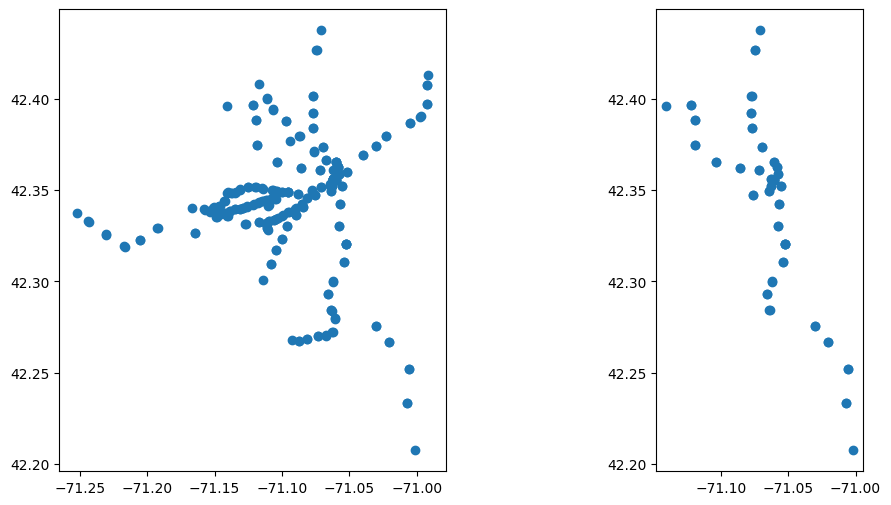

In [255]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
left_gdf.plot(ax=axes[0])
right_gdf.plot(ax=axes[1])